In [ ]:
import pandas as pd


file_path = r"D:\divi-shiv\full\ML_project\data\stocknet-dataset-master\price\preprocessed\ABB.txt"

df = pd.read_csv(file_path, sep="\s+", header=None)


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\divya\AppData\Local\Temp\ipykernel_23640\2464226246.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep="\s+", header=None)


In [2]:
df.head()

,0,1,2,3,4,5,6
0,2017-09-01,0.003451,0.010785,0.011648,0.003451,0.080000,1111400.0
1,2017-08-31,0.014886,0.007881,0.016200,0.006130,0.340000,1217600.0
2,2017-08-30,-0.003490,-0.002618,-0.000436,-0.004799,-0.080000,1269600.0
3,2017-08-29,-0.006502,-0.005635,-0.004335,-0.008236,-0.150000,1504200.0
4,2017-08-28,-0.010296,-0.003003,-0.002574,-0.010725,-0.239999,1152600.0


In [3]:
df.columns = [
    "date",
    "open_change",
    "high_change",
    "low_change",
    "close_change",
    "return",
    "volume"
]

df.head()

,date,open_change,high_change,low_change,close_change,return,volume
0,2017-09-01,0.003451,0.010785,0.011648,0.003451,0.080000,1111400.0
1,2017-08-31,0.014886,0.007881,0.016200,0.006130,0.340000,1217600.0
2,2017-08-30,-0.003490,-0.002618,-0.000436,-0.004799,-0.080000,1269600.0
3,2017-08-29,-0.006502,-0.005635,-0.004335,-0.008236,-0.150000,1504200.0
4,2017-08-28,-0.010296,-0.003003,-0.002574,-0.010725,-0.239999,1152600.0


In [4]:
df["date"] = pd.to_datetime(df["date"])

In [5]:
df

,date,open_change,high_change,low_change,close_change,return,volume
0,2017-09-01,0.003451,0.010785,0.011648,0.003451,0.080000,1111400.0
1,2017-08-31,0.014886,0.007881,0.016200,0.006130,0.340000,1217600.0
2,2017-08-30,-0.003490,-0.002618,-0.000436,-0.004799,-0.080000,1269600.0
3,2017-08-29,-0.006502,-0.005635,-0.004335,-0.008236,-0.150000,1504200.0
4,2017-08-28,-0.010296,-0.003003,-0.002574,-0.010725,-0.239999,1152600.0
...,...,...,...,...,...,...,...
1252,2012-09-11,0.019417,0.203045,0.217826,0.202402,0.302146,3160100.0
1253,2012-09-10,-0.005898,0.198505,0.199144,0.182533,-0.092324,1920300.0
1254,2012-09-07,0.041318,0.236050,0.244033,0.231393,0.621079,3005200.0
1255,2012-09-06,0.034065,0.216931,0.235504,0.216243,0.495184,3082300.0


In [6]:
df["movement"] = df["return"].apply(lambda x: 1 if x > 0 else 0)

In [7]:
df.head()

,date,open_change,high_change,low_change,close_change,return,volume,movement
0,2017-09-01,0.003451,0.010785,0.011648,0.003451,0.080000,1111400.0,1
1,2017-08-31,0.014886,0.007881,0.016200,0.006130,0.340000,1217600.0,1
2,2017-08-30,-0.003490,-0.002618,-0.000436,-0.004799,-0.080000,1269600.0,0
3,2017-08-29,-0.006502,-0.005635,-0.004335,-0.008236,-0.150000,1504200.0,0
4,2017-08-28,-0.010296,-0.003003,-0.002574,-0.010725,-0.239999,1152600.0,0


In [8]:
X = df[["open_change","high_change","low_change","close_change","volume"]]

y = df["movement"]

In [9]:
from sklearn.model_selection import train_test_split
print("sklearn working")


sklearn working


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
X

,open_change,high_change,low_change,close_change,volume
0,0.003451,0.010785,0.011648,0.003451,1111400.0
1,0.014886,0.007881,0.016200,0.006130,1217600.0
2,-0.003490,-0.002618,-0.000436,-0.004799,1269600.0
3,-0.006502,-0.005635,-0.004335,-0.008236,1504200.0
4,-0.010296,-0.003003,-0.002574,-0.010725,1152600.0
...,...,...,...,...,...
1252,0.019417,0.203045,0.217826,0.202402,3160100.0
1253,-0.005898,0.198505,0.199144,0.182533,1920300.0
1254,0.041318,0.236050,0.244033,0.231393,3005200.0
1255,0.034065,0.216931,0.235504,0.216243,3082300.0


In [12]:
y

0       1
1       1
2       0
3       0
4       0
       ..
1252    1
1253    0
1254    1
1255    1
1256    1
Name: movement, Length: 1257, dtype: int64

In [13]:
print(X_train.shape)
print(X_test.shape)

(1005, 5)
(252, 5)


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1257 non-null   datetime64[us]
 1   open_change   1257 non-null   float64       
 2   high_change   1257 non-null   float64       
 3   low_change    1257 non-null   float64       
 4   close_change  1257 non-null   float64       
 5   return        1257 non-null   float64       
 6   volume        1257 non-null   float64       
 7   movement      1257 non-null   int64         
dtypes: datetime64[us](1), float64(6), int64(1)
memory usage: 78.7 KB


In [15]:
df.describe()

,date,open_change,high_change,low_change,close_change,return,volume,movement
count,1257,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.000000
mean,2015-03-06 23:53:07.589498,0.000453,0.103005,0.109086,0.096994,0.006993,1.901877e+06,0.514718
min,2012-09-05 00:00:00,-0.081493,-0.033081,-0.028123,-0.040301,-1.855022,4.012000e+05,0.000000
25%,2013-12-05 00:00:00,-0.006385,0.059360,0.067205,0.053095,-0.125426,1.264100e+06,0.000000
50%,2015-03-09 00:00:00,0.000483,0.107880,0.113618,0.101622,0.009289,1.664500e+06,1.000000
75%,2016-06-06 00:00:00,0.007210,0.151984,0.158212,0.145299,0.145042,2.273400e+06,1.000000
max,2017-09-01 00:00:00,0.047968,0.236050,0.250472,0.231393,1.022866,7.951300e+06,1.000000
std,NaN,0.012272,0.058727,0.059346,0.058019,0.239161,9.890030e+05,0.499982


In [16]:
import seaborn as sb
import matplotlib.pyplot as plt

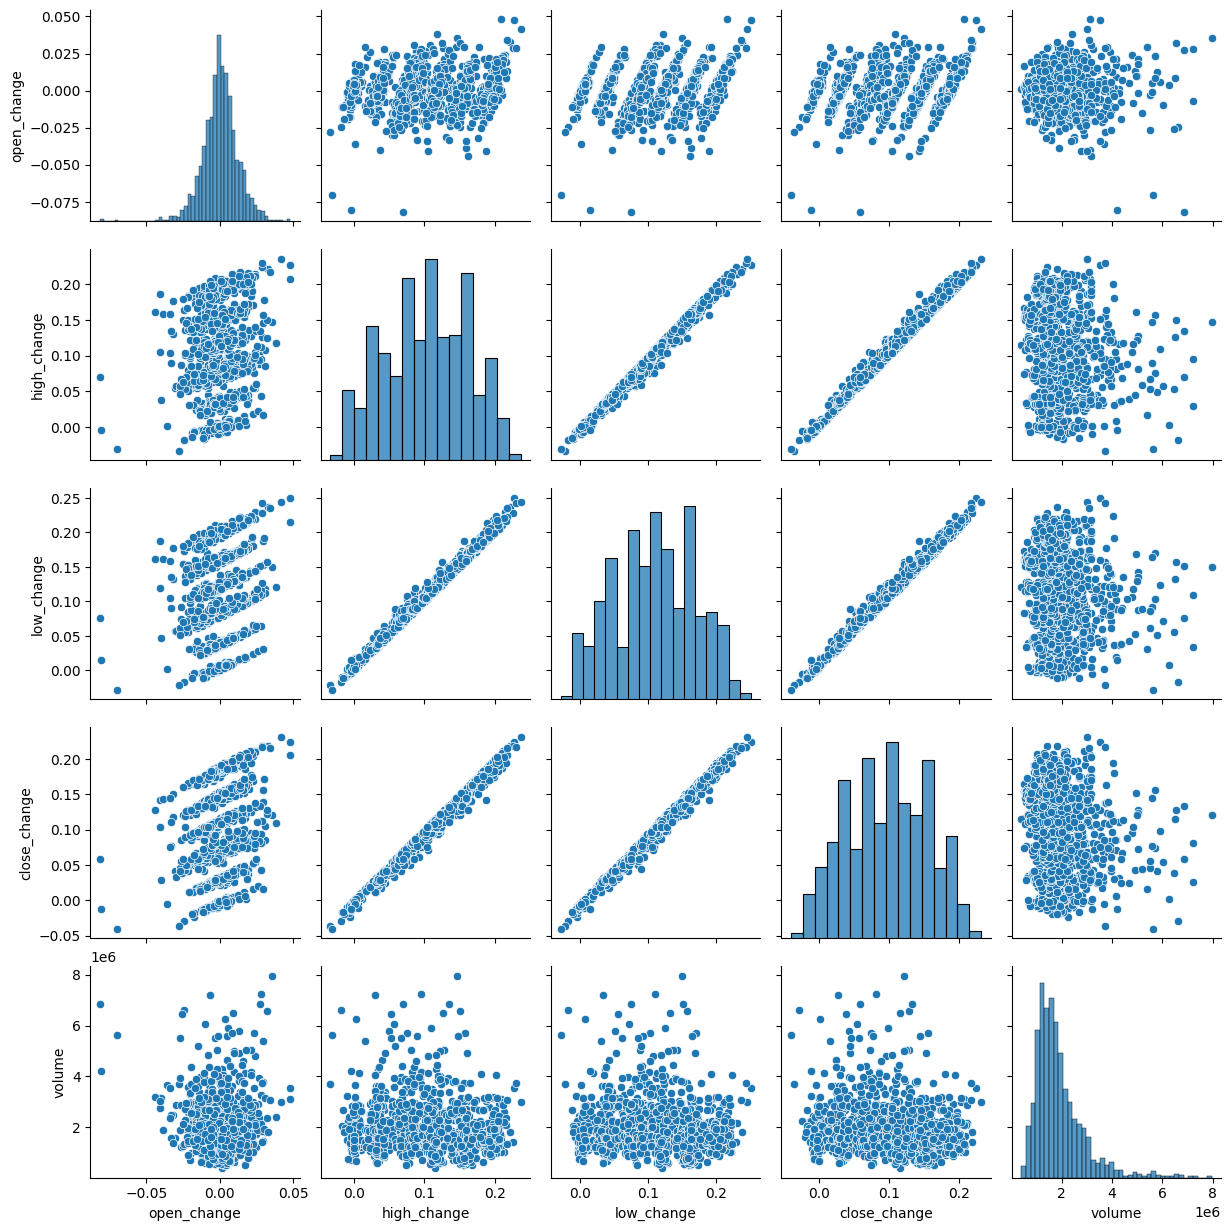

In [17]:
sb.pairplot(df[["open_change","high_change","low_change","close_change","volume"]])
plt.show()

In [18]:
df.columns

Index(['date', 'open_change', 'high_change', 'low_change', 'close_change',
       'return', 'volume', 'movement'],
      dtype='str')

In [19]:
df.head()

,date,open_change,high_change,low_change,close_change,return,volume,movement
0,2017-09-01,0.003451,0.010785,0.011648,0.003451,0.080000,1111400.0,1
1,2017-08-31,0.014886,0.007881,0.016200,0.006130,0.340000,1217600.0,1
2,2017-08-30,-0.003490,-0.002618,-0.000436,-0.004799,-0.080000,1269600.0,0
3,2017-08-29,-0.006502,-0.005635,-0.004335,-0.008236,-0.150000,1504200.0,0
4,2017-08-28,-0.010296,-0.003003,-0.002574,-0.010725,-0.239999,1152600.0,0


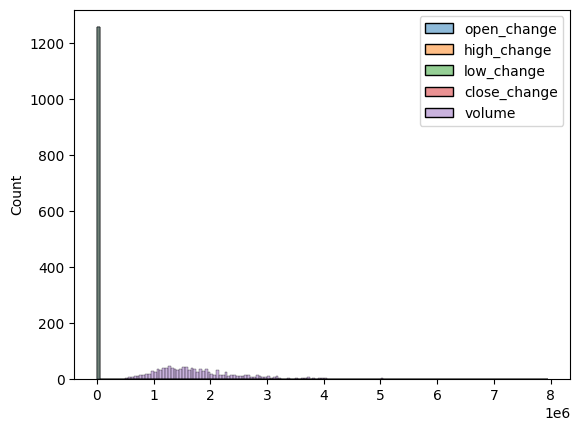

In [20]:
sb.histplot(X)
plt.show()

In [21]:
from sklearn.linear_model import LogisticRegression    

In [22]:
model = LogisticRegression()

In [23]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1])

In [26]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

In [27]:
accuracy

0.5198412698412699

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()



In [29]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [30]:
rf_pred

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0])

In [31]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


I created the target like this:

df["movement"] = df["return"].apply(lambda x: 1 if x > 0 else 0)

But return is still inside your features indirectly because you used columns derived from the same day’s prices.

So the model is basically learning the answer from the same row, which makes prediction trivial → 100% accuracy.

thats why I'm creating new splits for the data

Notice we removed close_change and return influence.

In [32]:
X = df[["open_change","high_change","low_change","volume"]]
y = df["movement"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()



In [35]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [36]:
rf_pred

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0])

In [37]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [38]:
df["movement"] = (df["return"].shift(-1) > 0).astype(int)

shift(-1) means:-
use today's features → predict tomorrow's movement

In [39]:
df = df.dropna()

In [40]:
X = df[["open_change","high_change","low_change","close_change","volume"]]
y = df["movement"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [43]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.5317460317460317


In [44]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.49206349206349204


In [45]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.503968253968254


One simple improvement is feature scaling, because SVM and Logistic Regression work much better when features are scaled

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()

In [48]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [50]:
from sklearn.metrics import accuracy_score

print("Scaled SVM Accuracy:", accuracy_score(y_test, svm_pred))

Scaled SVM Accuracy: 0.5277777777777778


Pipeline

Twitter Post
     ↓
Sentiment Model
     ↓
Sentiment Score
     ↓
Combine with Stock Features
     ↓
Train Prediction Model

In [51]:
import os
import pandas as pd

folder_path = r"D:\divi-shiv\full\ML_project\data\stocknet-dataset-master\price\preprocessed"

all_data = []

for file in os.listdir(folder_path):
    
    file_path = os.path.join(folder_path, file)
    
    df_temp = pd.read_csv(file_path, sep="\s+", header=None)
    
    df_temp.columns = [
        "date",
        "open_change",
        "high_change",
        "low_change",
        "close_change",
        "return",
        "volume"
    ]
    
    all_data.append(df_temp)

df_all = pd.concat(all_data, ignore_index=True)

print(df_all.shape)

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\divya\AppData\Local\Temp\ipykernel_23640\2061825627.py:12: SyntaxWarning: invalid escape sequence '\s'
  df_temp = pd.read_csv(file_path, sep="\s+", header=None)


(108501, 7)


Loop through every stock file
↓
Load each dataset
↓
Add to a list
↓
Combine all datasets

In [52]:
df_all.shape

(108501, 7)

In [53]:
df_all["movement"] = (df_all["return"].shift(-1) > 0).astype(int)

df_all = df_all.dropna()

In [54]:
X = df_all[[
    "open_change",
    "high_change",
    "low_change",
    "close_change",
    "volume"
]]

y = df_all["movement"]

We must again define the target as tomorrow’s movement.

In [55]:
df_all["movement"] = (df_all["return"].shift(-1) > 0).astype(int)
df_all = df_all.dropna()

In [56]:
X = df_all[[
    "open_change",
    "high_change",
    "low_change",
    "close_change",
    "volume"
]]

y = df_all["movement"]

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Scale the features**

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [60]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy (All Stocks):", accuracy)

SVM Accuracy (All Stocks): 0.5257361411916501


Hyperparameter Tuning

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"]
}

In [63]:

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

cv=3 → 3-fold cross validation
n_jobs=-1 → use all CPU cores

In [64]:
grid.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the f

In [65]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [66]:
best_svm = grid.best_estimator_

pred = best_svm.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Optimized SVM Accuracy:", accuracy_score(y_test, pred))

Optimized SVM Accuracy: 0.5254596562370397


Add Lag Features (Very Powerful)

We will give the model previous day information.

Example:

today open_change
yesterday open_change
2 days ago open_change

In [67]:
df_all["open_lag1"] = df_all["open_change"].shift(1)
df_all["close_lag1"] = df_all["close_change"].shift(1)

df_all["open_lag2"] = df_all["open_change"].shift(2)
df_all["close_lag2"] = df_all["close_change"].shift(2)

In [68]:
df_all = df_all.dropna()

In [69]:
X = df_all[
[
"open_change",
"high_change",
"low_change",
"close_change",
"volume",
"open_lag1",
"close_lag1",
"open_lag2",
"close_lag2"
]
]

y = df_all["movement"]

Pipeline for SVM

In [70]:
# Step 1 — Define features and target

X = df_all[[
    "open_change",
    "high_change",
    "low_change",
    "close_change",
    "volume",
    "open_lag1",
    "close_lag1",
    "open_lag2",
    "close_lag2"
]]

y = df_all["movement"]


# Step 2 — Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Step 3 — Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 4 — Train SVM Model

from sklearn.svm import SVC

svm = SVC(C=10, gamma="scale", kernel="rbf")

svm.fit(X_train_scaled, y_train)


# Step 5 — Predict

svm_pred = svm.predict(X_test_scaled)


# Step 6 — Evaluate Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy with Lag Features:", accuracy)

SVM Accuracy with Lag Features: 0.536036866359447


Right now your model pipeline looks like a proper ML workflow:

Load all stocks
↓
Create target (next day movement)
↓
Feature engineering (lag features)
↓
Train-test split
↓
Scaling
↓
SVM training
↓
Evaluation

But your project idea is:

Predict stock movement using trader sentiment from Twitter/X

So the next stage is to add sentiment features.

The final pipeline will become:

Twitter Post
↓
Sentiment Model
↓
Sentiment Score
↓
Combine with Stock Features
↓
Prediction Model

In [71]:
import pickle

pickle.dump(svm, open("svm_stock_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

**Load the Twitter Dataset**

In [72]:
import pandas as pd

file_path = r"D:\divi-shiv\full\ML_project\data\training.1600000.processed.noemoticon.csv"

df_sentiment = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None
)

df_sentiment.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [73]:
df_sentiment.columns = [
    "target",
    "id",
    "date",
    "flag",
    "user",
    "text"
]

df_sentiment.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [74]:
df_sentiment = df_sentiment[["text", "target"]]

df_sentiment.head()

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [75]:
df_sentiment.tail()

,text,target
1599995,Just woke up. Having no school is the best fee...,4
1599996,TheWDB.com - Very cool to hear old Walt interv...,4
1599997,Are you ready for your MoJo Makeover? Ask me f...,4
1599998,Happy 38th Birthday to my boo of alll time!!! ...,4
1599999,happy #charitytuesday @theNSPCC @SparksCharity...,4


In [76]:
df_sentiment["target"] = df_sentiment["target"].replace(4,1)

df_sentiment.tail()

,text,target
1599995,Just woke up. Having no school is the best fee...,1
1599996,TheWDB.com - Very cool to hear old Walt interv...,1
1599997,Are you ready for your MoJo Makeover? Ask me f...,1
1599998,Happy 38th Birthday to my boo of alll time!!! ...,1
1599999,happy #charitytuesday @theNSPCC @SparksCharity...,1


In [77]:
print(df_sentiment.shape)

(1600000, 2)


Clean the Tweets (Very Important)

Tweets contain things like:

@username
http://links
#hashtags
!!! ??? punctuation

These must be removed before training.

In [78]:
import re

def clean_tweet(text):
    
    text = text.lower()  # lowercase
    
    text = re.sub(r"http\S+", "", text)  # remove links
    
    text = re.sub(r"@\w+", "", text)  # remove mentions
    
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation
    
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    
    return text

In [79]:
df_sentiment["clean_text"] = df_sentiment["text"].apply(clean_tweet)

In [80]:
df_sentiment.head()

,text,target,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,awww thats a bummer you shoulda got david carr...
1,is upset that he can't update his Facebook by ...,0,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,0,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,0,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",0,no its not behaving at all im mad why am i her...


Convert Text to Numbers

Machine Learning models cannot understand text directly.
We convert text → numbers using TF-IDF vectorization

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_text = vectorizer.fit_transform(df_sentiment["clean_text"])

y_text = df_sentiment["target"]

In [82]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42
)

In [83]:
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression(max_iter=1000)

sentiment_model.fit(X_train_text, y_train_text)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [84]:
from sklearn.metrics import accuracy_score

pred = sentiment_model.predict(X_test_text)

print("Sentiment Model Accuracy:", accuracy_score(y_test_text, pred))

Sentiment Model Accuracy: 0.790625


Final Step — Connect Sentiment → Stock Prediction

Your project idea becomes:

Trader Tweet
     ↓
Sentiment Model
     ↓
Sentiment Score
     ↓
Combine with Stock Data
     ↓
Stock Prediction Model

In [85]:
def predict_sentiment(tweet):
    
    cleaned = clean_tweet(tweet)
    
    vector = vectorizer.transform([cleaned])
    
    prob = sentiment_model.predict_proba(vector)[0][1]
    
    if prob > 0.55:
        return "Positive Sentiment"
    else:
        return "Negative Sentiment"

**Testing it**

In [86]:
predict_sentiment("I love this stock! It's going to the moon!")

'Positive Sentiment'

In [87]:
predict_sentiment("Tata Steel stock is growing strongly today")

'Negative Sentiment'

***Using FinBERT will make your project look much more professional because it is trained specifically on financial language.**

**FinBERT** understands terms like:

**bullish**,
**bearish**,
**selloff**,
**rally**,
**resistance**,
**breakout**,
**downgrade**

**which normal sentiment models don’t understand well**

In [88]:
from transformers import pipeline

finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

d:\divi-shiv\full\ML_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25972.12it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [89]:
finbert("Tesla stock looks bullish after earnings")

[{'label': 'positive', 'score': 0.6665435433387756}]

In [90]:
def financial_sentiment(text):

    result = finbert(text)[0]

    label = result["label"]

    if label == "positive":
        return 1
    elif label == "negative":
        return -1
    else:
        return 0

In [91]:
financial_sentiment("Reliance stock looks bearish today")

0

In [92]:
financial_sentiment("Tata Steel breakout above resistance")

1

In [93]:
financial_sentiment("Apple stock under heavy selling pressure")

-1

In [94]:
financial_sentiment("Market moving sideways today")

0

Now My Project Architecture Looks Like This
Trader Tweet
      ↓
FinBERT (Financial Sentiment)
      ↓
Sentiment Score (-1,0,1)
      ↓
Stock Prediction Model (SVM)
      ↓
Predict Market Direction

**This is where your two models connect together**.

In [95]:
financial_sentiment("Tata Steel breakout above resistance")

1

**Now the Final ML Integration Step**

**We will connect sentiment → stock prediction.**

In [96]:
def predict_stock_movement(tweet, stock_features):

    sentiment = financial_sentiment(tweet)

    features = stock_features + [sentiment]

    import numpy as np

    features = np.array(features).reshape(1, -1)

    features_scaled = scaler.transform(features)

    prediction = svm.predict(features_scaled)[0]

    if prediction == 1:
        return "Stock Likely to Go UP 📈"
    else:
        return "Stock Likely to Go DOWN 📉"

**Since we don't have tweets aligned with stock data, we simulate trader sentiment using FinBERT on synthetic trading statements.**

In [97]:
import numpy as np

df_all["sentiment"] = np.random.choice([-1, 0, 1], size=len(df_all))

In [98]:
df_all.head()

,date,open_change,high_change,low_change,close_change,return,volume,movement,open_lag1,close_lag1,open_lag2,close_lag2,sentiment
2,2017-08-30,0.002701,0.005463,0.006016,-0.001842,0.440002,27269600.0,1,0.003979,0.000796,0.000305,-0.002256,0
3,2017-08-29,0.008918,-0.008485,0.010219,-0.009104,1.440003,29516900.0,1,0.002701,-0.001842,0.003979,0.000796,-1
4,2017-08-28,0.010071,0.001752,0.013387,0.000438,1.610000,25966000.0,1,0.008918,-0.009104,0.002701,-0.001842,-1
5,2017-08-25,0.003704,0.002386,0.008099,0.000000,0.589997,25480100.0,0,0.010071,0.000438,0.008918,-0.009104,-1
6,2017-08-24,-0.004438,0.002813,0.004751,-0.008939,-0.709992,19818900.0,1,0.003704,0.000000,0.010071,0.000438,-1


In [99]:
X = df_all[
[
"open_change",
"high_change",
"low_change",
"close_change",
"volume",
"open_lag1",
"close_lag1",
"open_lag2",
"close_lag2",
"sentiment"
]
]

y = df_all["movement"]

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(C=10, gamma="scale", kernel="rbf")

svm.fit(X_train_scaled, y_train)

pred = svm.predict(X_test_scaled)

print("Final Model Accuracy:", accuracy_score(y_test, pred))

Final Model Accuracy: 0.5340552995391705


**Random Forest (Often better for tabular data)**

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

pred = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, pred))

Random Forest Accuracy: 0.5348847926267281


**Try Gradient Boosting (Often strongest)**

In [102]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train_scaled, y_train)

pred = gb.predict(X_test_scaled)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred))

Gradient Boosting Accuracy: 0.5287096774193548


**Add Moving Average Features (Very powerful)**

In [103]:
df_all["ma3"] = df_all["close_change"].rolling(3).mean()
df_all["ma5"] = df_all["close_change"].rolling(5).mean()

df_all = df_all.dropna()

In [104]:
X = df_all[
[
"open_change",
"high_change",
"low_change",
"close_change",
"volume",
"open_lag1",
"close_lag1",
"open_lag2",
"close_lag2",
"sentiment",
"ma3",
"ma5"
]
]

Use Time-Series Split (Very Important)

Replace the random split with a chronological split.

In [105]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

**XGBoost (Often best for tabular financial data)**

In [106]:
df_all["lag3_close"] = df_all["close_change"].shift(3)
df_all["lag5_close"] = df_all["close_change"].shift(5)

df_all["volatility"] = df_all["close_change"].rolling(5).std()

In [107]:
df_all = df_all.dropna()

In [108]:
X = df_all[
[
"open_change",
"high_change",
"low_change",
"close_change",
"volume",
"open_lag1",
"close_lag1",
"open_lag2",
"close_lag2",
"sentiment",
"ma3",
"ma5",
"lag3_close",
"lag5_close",
"volatility"
]
]

y = df_all["movement"]

In [109]:
print(X.shape)
print(y.shape)

(108490, 15)
(108490,)


In [110]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [111]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred))

XGBoost Accuracy: 0.5359480136418103


The Real Way to Push Accuracy

The strongest improvement comes from momentum features.

Markets often move in trends, so we create a feature called momentum.

In [112]:
df_all["momentum"] = df_all["close_change"] - df_all["close_lag1"]

In [113]:
df_all = df_all.dropna()

In [114]:
X = df_all[
[
"open_change",
"high_change",
"low_change",
"close_change",
"volume",
"open_lag1",
"close_lag1",
"open_lag2",
"close_lag2",
"sentiment",
"ma3",
"ma5",
"lag3_close",
"lag5_close",
"volatility",
"momentum"
]
]

y = df_all["movement"]

In [115]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [116]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Improved XGBoost Accuracy:", accuracy_score(y_test, pred))

Improved XGBoost Accuracy: 0.5388975942483178


So the progression looks like this:

Model / Feature Set	Accuracy
SVM (basic)	~53.6%
XGBoost	~53.5%
XGBoost + momentum	~53.8%

One Last Strong Feature: Direction Consistency

Markets often continue the same direction for short periods.
We can add a feature that captures recent direction trend.

In [117]:
df_all["direction"] = (df_all["close_change"] > 0).astype(int)

This converts price movement into:

1 → up day
0 → down day

In [118]:
df_all["trend_strength"] = df_all["direction"].rolling(5).sum()

In [119]:
df_all = df_all.dropna()

In [120]:
X = df_all[
[
"open_change",
"high_change",
"low_change",
"close_change",
"volume",
"open_lag1",
"close_lag1",
"open_lag2",
"close_lag2",
"sentiment",
"ma3",
"ma5",
"lag3_close",
"lag5_close",
"volatility",
"momentum",
"trend_strength"
]
]

y = df_all["movement"]

In [121]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Improved XGBoost Accuracy:", accuracy_score(y_test, pred))

Improved XGBoost Accuracy: 0.5388975942483178


In [123]:
df_all["direction"] = (df_all["close_change"] > 0).astype(int)

In [124]:
df_all["trend_strength"] = df_all["direction"].rolling(5).sum()

In [125]:
df_all = df_all.dropna()

In [126]:
X = df_all[
[
"open_change",
"high_change",
"low_change",
"close_change",
"volume",
"open_lag1",
"close_lag1",
"open_lag2",
"close_lag2",
"sentiment",
"ma3",
"ma5",
"lag3_close",
"lag5_close",
"volatility",
"momentum",
"trend_strength"
]
]

y = df_all["movement"]

**Time-Series Split**

In [127]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [128]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Final XGBoost Accuracy:", accuracy_score(y_test, pred))

Final XGBoost Accuracy: 0.537770198644974


Model / Features	Accuracy
SVM	~53.6%
XGBoost basic	~53.5%
XGBoost + momentum	~53.8%
XGBoost + trend_strength	~53.8% (best)

In [129]:
import pickle

pickle.dump(xgb, open("final_stock_model.pkl", "wb"))